In [1]:
import torch
from models import causal_model,STGCN
import tools
from torch.utils.data import DataLoader
from torch.optim import Adam
import numpy as np
from torch import nn
import yaml
import os
import logging
import tools.data_tools
import time
from itertools import product
import csv
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.optim.lr_scheduler import ReduceLROnPlateau
import pandas as pd
import matplotlib.pyplot as plt
import tqdm
import random

In [25]:
# with open('models\config.yaml', 'r') as f:
#     config = yaml.safe_load(f)

# if you want to use different dataset:
with open('models\config2.yaml', 'r') as f:
    config = yaml.safe_load(f)
    
    
train_data, val_data, test_data, scaler,valid_grid=tools.data_tools.get_datasets(config['data_dir'],config)
adj_mx =  tools.data_tools.expand_adjacency_matrix(np.load(config['adj_mx_file']), config['num_nodes'])[valid_grid][:,valid_grid]
config['num_nodes']=len(valid_grid)
config['train_months']=train_data.data.shape[1]//(30*24)+1
device=config.get('device')
device=torch.device('cuda:0')
print(config)
model=causal_model.CausalModel_quantile_regress(STGCN.STGCN,config,adj_mx)
node_num=len(valid_grid)

model=model.to(device)
train_loader = DataLoader(train_data, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_data, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
model.load_state_dict(torch.load(r'final_models\bike\model.pth'))
# model.load_state_dict(torch.load(r'final_models\taxi\model.pth'))

{'data_dir': './data/nycbike', 'model_dir': './saved_models', 'checkpoint_dir': './checkpoints', 'num_nodes': 101, 'batch_size': 128, 'num_epochs': 300, 'learning_rate': 0.005, 'dataset_name': 'bike', 'feature_dim_out': 16, 'domain_dim': 4, 'dropout': 0.3, 'input_window': 6, 'device': 'cuda:0', 'train_months': 12, 'adj_mx_file': 'bike_adjacency_matrix.npy', 'model_name': 'DCRNN'}


<All keys matched successfully>

In [19]:
def calculate_coverage(true_values, predicted_means, predicted_lower_bounds, predicted_upper_bounds):
    coverage_rates = []

    for true_val, lower_bound, upper_bound in zip(true_values, predicted_lower_bounds, predicted_upper_bounds):
        # 检查每个真实值是否在预测的上下界内
        coverage = np.logical_and(lower_bound <= true_val, true_val <= upper_bound)

        coverage_rates.append(coverage)

    return coverage_rates
def report_result(coverage, upper_bound, lower_bound, true_values, alpha=0.1):
    """
    计算覆盖率、区间长度以及 MIS，并返回结果。
    
    参数:
        coverage (array-like): 预测区间覆盖率的布尔值数组。
        upper_bound (array-like): 预测区间的上限。
        lower_bound (array-like): 预测区间的下限。
        true_values (array-like): 实际值。
        alpha (float): 显著性水平，默认为 0.05。
    
    返回:
        pd.DataFrame: 包含覆盖率、区间长度和 MIS 的数据框。
    """
    result = dict()
    coverage = np.array(coverage)
    for i in range(4):
        # 定义区间范围
        if i <= 2:
            range_start = i * (24 * 30)
            range_end = (i + 1) * (24 * 30)
        else:
            range_start = i * (24 * 30)
            range_end = len(coverage)

        # 提取区间对应数据
        coverage_segment = coverage[range_start:range_end]
        upper_bound_segment = upper_bound[range_start:range_end]
        lower_bound_segment = lower_bound[range_start:range_end]
        true_values_segment = true_values[range_start:range_end]

        # 计算覆盖率和区间长度
        result[f'coverage_{i}'] = np.mean(coverage_segment)
        result[f'interval_len_{i}'] = np.mean(upper_bound_segment - lower_bound_segment)
        result[f'minLC_{i}'] = np.mean(coverage_segment,axis=(0,-1)).min()

        # 计算 MIS
        interval_length = upper_bound_segment - lower_bound_segment
        penalty_below = 2 / alpha * (lower_bound_segment - true_values_segment) * (true_values_segment < lower_bound_segment)
        penalty_above = 2 / alpha * (true_values_segment - upper_bound_segment) * (true_values_segment > upper_bound_segment)
        mis = np.mean(interval_length + penalty_below + penalty_above)

        result[f'MIS_{i}'] = mis

    return pd.DataFrame(result, index=[0])



In [5]:
import numpy as np

def calculate_conformity_scores(true_vals, q_lo, q_hi):
    """
    计算符合性分数 Ei。
    
    参数:
    - true_vals: NumPy 数组，真实值数组。
    - q_lo: NumPy 数组，下分位数数组。
    - q_hi: NumPy 数组，上分位数数组。
    
    返回:
    - conformity_scores: NumPy 数组，符合性分数数组。
    """
    # 检查输入数组长度是否一致
    if not (len(true_vals) == len(q_lo) == len(q_hi)):
        print(true_vals.shape, q_lo.shape, q_hi.shape)
        raise ValueError("输入数组的长度必须一致")
    
    # 使用矢量化操作计算符合性分数
    conformity_scores = np.where(
        true_vals < q_lo,
        q_lo - true_vals,
        np.where(
            true_vals > q_hi,
            true_vals - q_hi,
            np.maximum(q_lo - true_vals, true_vals - q_hi)
        )
    )
    
    return conformity_scores


In [26]:

model.eval()  # 设置模型为评估模式
true_values = []
predictions = []
lower_bounds = []
upper_bounds = []
alpha=0.1
# 第一步：在验证集上计算初始残差集


conformity_scores = []

conformity_scores_up=[]
conformity_scores_low=[]
def get_quantile_inaxis(x, y, axis):
    """
    计算指定轴上的每个切片的分位数。

    参数：
        x (numpy.ndarray): 输入多维数组。
        y (numpy.ndarray): 分位数值数组，长度需与 x 在指定轴上的大小相等。
        axis (int): 指定的轴。

    返回：
        numpy.ndarray: 计算出的分位数数组。
    """
    if x.shape[axis] != len(y):
        raise ValueError("The length of y must be equal to the size of the specified axis in x.")
    
    # 创建一个索引数组
    indices = [slice(None)] * x.ndim
    result = []

    for i, quantile in enumerate(y):
        indices[axis] = i
        this_x = x[tuple(indices)]  # 获取指定轴上的切片
        this_quantile = np.quantile(this_x, quantile)
        result.append(this_quantile)
    
    return np.array(result)
for inputs, targets in val_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    
    # 模型输出上下分位数
    with torch.no_grad():
        _,q_lo, q_hi = model(inputs)
    
    q_lo = q_lo.cpu().numpy()
    q_hi = q_hi.cpu().numpy()
    true_vals = targets.cpu().numpy()
    
    # 计算符合性分数 Ei
    conformity_score_low=q_lo-targets.cpu().numpy()
    conformity_score_high=targets.cpu().numpy()-q_hi
   
    conformity_scores_low.append(conformity_score_low)
    conformity_scores_up.append(conformity_score_high)
    

conformity_scores_low = np.concatenate(conformity_scores_low)
conformity_scores_up = np.concatenate(conformity_scores_up)

initial_scores = conformity_scores.copy()  # 保留初始分数集

# 第二步：在测试集上生成预测区间
theta_t=np.array(node_num*[0.1])
theta=[]
lr = 0.01   # 学习率

beta2 = 0.99   # 二阶动量的衰减率
epsilon = 1e-8  # 避免除零的小常数

# 假设 true_val, lower_bound, upper_bound, 和 theta_t 都已经定义
m_t = np.zeros_like(theta_t)  # 一阶动量
v_t = np.zeros_like(theta_t)  # 二阶动量
t = 0  # 时间步
grad_0=np.zeros_like(theta_t)
lr_0=np.ones_like(theta_t)*0.001
for inputs, targets in test_loader:
    theta.append(theta_t.copy())
    
    q_alpha_low=get_quantile_inaxis(conformity_scores_low,1-theta_t,axis=2)
    q_alpha_high=get_quantile_inaxis(conformity_scores_up,1-theta_t,axis=2)
    
    q_alpha_low=q_alpha_low.reshape(1,1,node_num,1).repeat(2,-1)
    q_alpha_high=q_alpha_high.reshape(1,1,node_num,1).repeat(2,-1)
    # print(q_alpha.shape)

    
    inputs, targets = inputs.to(device), targets.to(device)
   
    # 模型输出上下分位数
    with torch.no_grad():
        _,q_lo, q_hi = model(inputs)
    
    q_lo = q_lo.cpu().numpy()
    q_hi = q_hi.cpu().numpy()
    true_val = targets.cpu().numpy()
    
    # 根据 dynamic_residuals 参数选择残差更新模式
    
    
    conformity_score_low=q_lo-targets.cpu().numpy()
    conformity_score_high=targets.cpu().numpy()-q_hi
    
    conformity_scores_up=np.concatenate([conformity_scores_up, conformity_score_high])  # 添加最新分数
    conformity_scores_low=np.concatenate([conformity_scores_low, conformity_score_low])  # 添加最新分数
    
   
    conformity_scores_up=conformity_scores_up[1:]  # 移除最旧分数
    conformity_scores_low=conformity_scores_low[1:]  # 移除最旧分数
   
    lower_bound = q_lo - q_alpha_low
    upper_bound = q_hi + q_alpha_high
    prediction = (q_lo + q_hi ) / 2  # 预测均值为中点

    # 保存结果
    true_values.append(true_val)
    predictions.append(prediction)
    lower_bounds.append(lower_bound)
    upper_bounds.append(upper_bound)

    # 如果不使用动态残差，则重置 residuals
   
    for k in range(len(theta_t)):
        
        coverage_errors_this = (true_val[:,:,k,:] < lower_bound[:,:,k,:]) | (true_val[:,:,k,:] > upper_bound[:,:,k,:])
        err_t = np.mean(coverage_errors_this)
        
        # # # 计算梯度（假设是 -err_t，您可以根据实际计算梯度）
        grad_t = alpha-err_t  # 这里假设 err_t 越小，theta_t 越大，所以梯度是负的
        
        
        
       
        t += 1  # 更新时间步


        v_t[k] = beta2 * v_t[k] + (1 - beta2) * grad_t ** 2
        
       
        v_hat = v_t[k] / (1 - beta2 ** t)
        
        # 更新参数
        theta_t[k] = theta_t[k] + lr * grad_t / (np.sqrt(v_hat) + epsilon)
        
        # 限制 theta_t 的范围
        theta_t[k] = max(0.01, theta_t[k])
        theta_t[k] = min(0.99, theta_t[k])
    

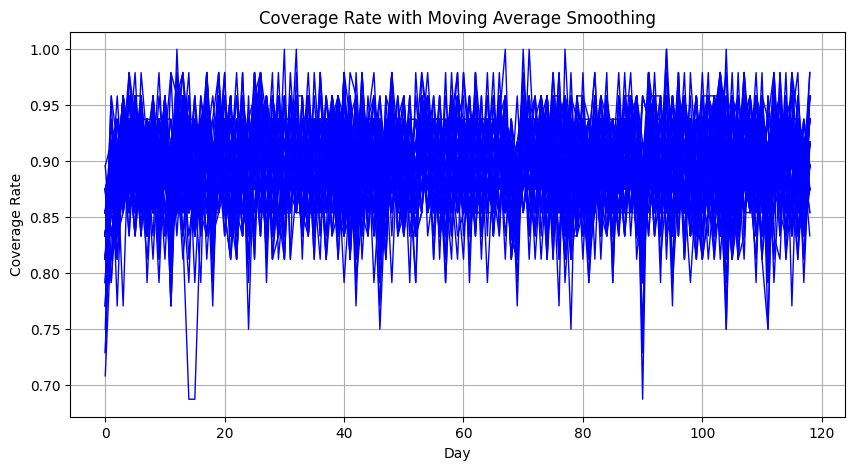

In [27]:
s = calculate_coverage(true_values, predictions, lower_bounds, upper_bounds)

cov = np.array([np.array(s[i*24:(i+1)*24]).mean(axis=(0,-1)) for i in range(len(s)//24)]).mean(axis=1)


# 绘图
plt.figure(figsize=(10, 5))
plt.plot(cov[:,0], label='Smoothed Coverage', color='b',linewidth=1)
plt.xlabel('Day')
plt.ylabel('Coverage Rate')
plt.title('Coverage Rate with Moving Average Smoothing')
# plt.legend()
# plt.ylim(0.8,1)
plt.grid()
plt.show()

In [28]:
report_result(np.concatenate(s),np.concatenate(upper_bounds),np.concatenate(lower_bounds),np.concatenate(true_values))

,coverage_0,interval_len_0,minLC_0,MIS_0,coverage_1,interval_len_1,minLC_1,MIS_1,coverage_2,interval_len_2,minLC_2,MIS_2,coverage_3,interval_len_3,minLC_3,MIS_3
0,0.894946,0.268319,0.884028,0.358625,0.897662,0.263328,0.892361,0.348544,0.897752,0.286314,0.889583,0.372512,0.896317,0.349085,0.890056,0.465213
